# Topic Modeling with Latent Dirichlet Allocation  

## Corpus : Legislative Elections Candidates Manifestos in France (1973-1993)

# Set up

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import math
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import  LatentDirichletAllocation 
import spacy
import numpy as np
from gensim.models import LdaModel, CoherenceModel
from gensim import corpora
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
!pip install pyLDAvis
import pyLDAvis 
import pyLDAvis.lda_model
import pandas as pd
import numpy as np
from scipy.stats import entropy
import sys
!{sys.executable} -m pip install pyLDAvis scikit-learn --upgrade



# Define paths relative to this notebook's location 
current_dir = Path.cwd()
project_root = current_dir.parent
meta_dir = project_root / "metadata"
data_dir = project_root / "data"
spacy_model_path = project_root / "fr_core_news_md-3.8.0-py3-none-any.whl"
nlp = spacy.load("fr_core_news_md")

In [3]:
master_df = pd.read_parquet(data_dir / 'cleaned_master_data.parquet')
filtered_df = master_df[master_df['titulaire-sexe'].isin(['femme', 'homme'])]

# Model Training

## 10 TOPIC MODEL

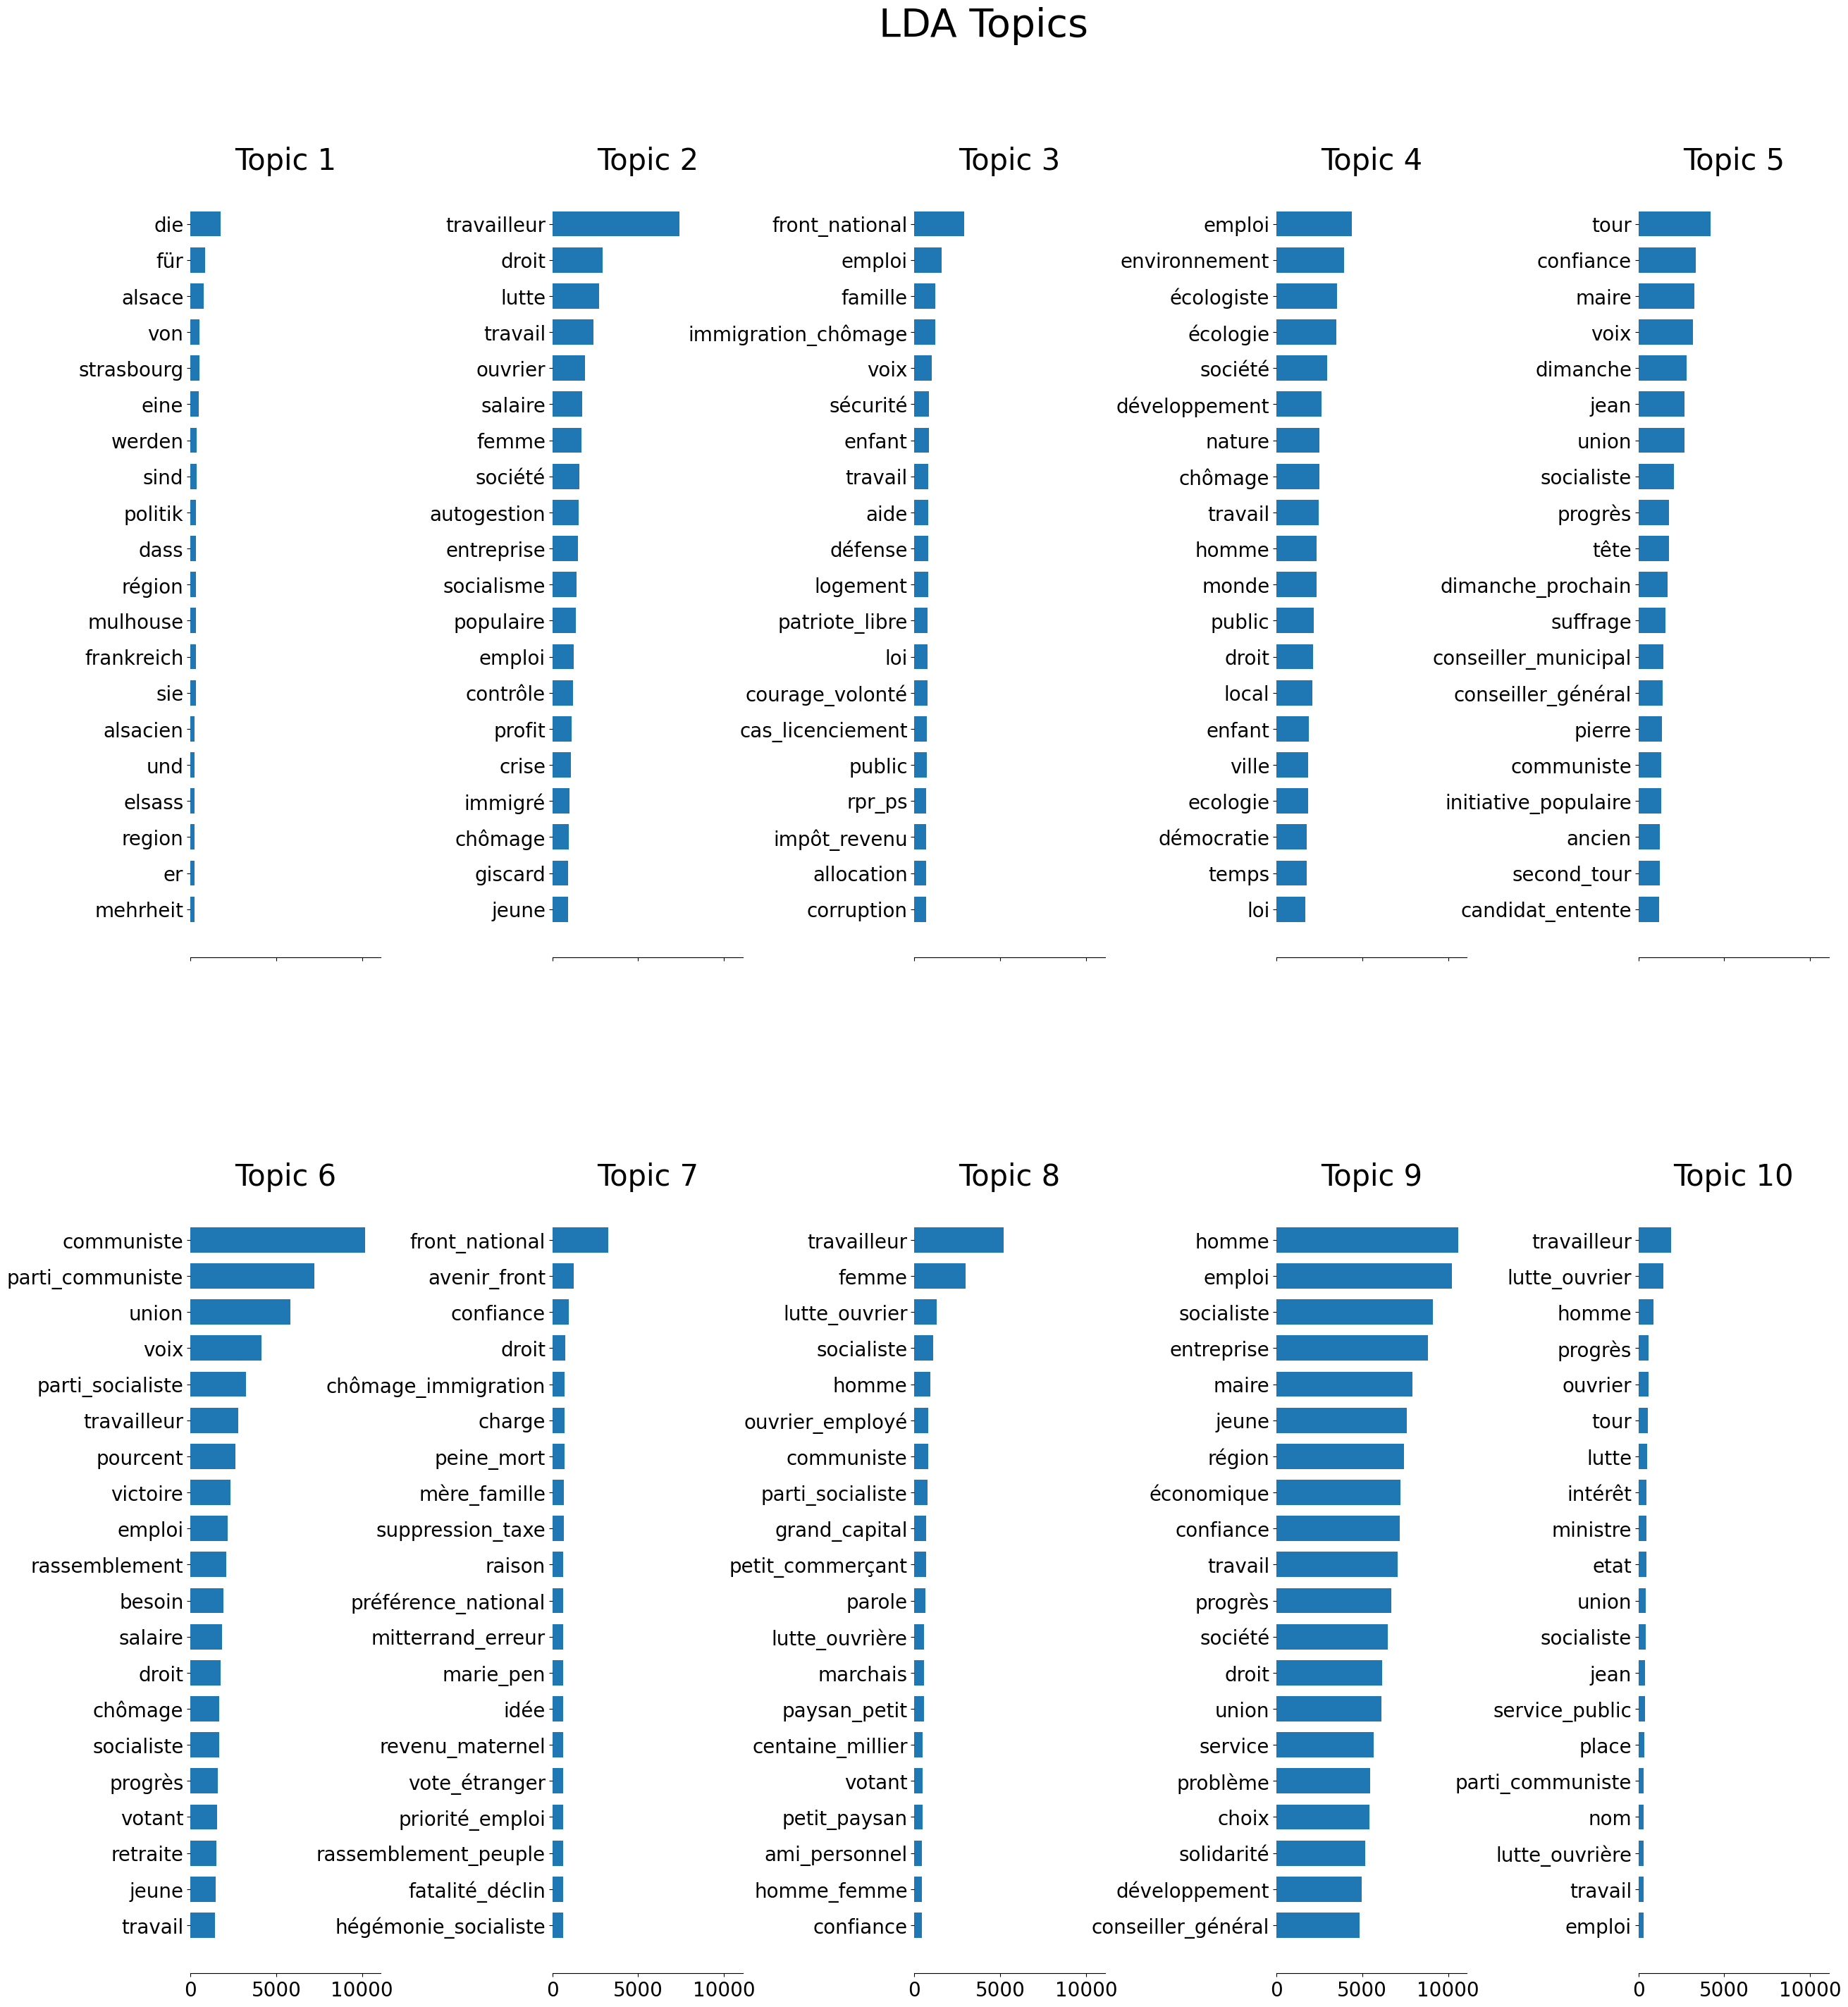

In [18]:
# 1. Prepare the Data
documents=filtered_df['final_tokens']

# 2. Define Parameters
n_topics = 10
n_top_words = 20

# 3. Vectorize the Text - BoW representation
tf_vectorizer = CountVectorizer(max_df=0.8, min_df=5)
tf = tf_vectorizer.fit_transform(documents)

# 4. Fit the LDA Model
lda_ten = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method="online",
    learning_offset=50.0,
    random_state=42,
)
lda_ten.fit(tf)

# 5. Plotting Function
def plot_top_words(model, vectorizer, n_top_words, title, nb_lines):
    feature_names = vectorizer.get_feature_names_out()
    
    fig, axes = plt.subplots(nb_lines, 5, figsize=(30, 30), sharex=True)
    axes = axes.flatten()
    
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
            
    fig.suptitle(title, fontsize=40)
    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

# 6. Plot the results
plot_top_words(lda_ten, tf_vectorizer, n_top_words, "LDA Topics", nb_lines=2)

### Explore topics

In [8]:
# Enable notebook visualization
pyLDAvis.enable_notebook()

# Prepare the data 
lda_display_ten = pyLDAvis.lda_model.prepare(lda_ten, tf, tf_vectorizer, sort_topics =False)

# Display the interactive chart
pyLDAvis.display(lda_display_ten)

### Obtain topics coherence

In [10]:
# Extract feature names 
feature_names = tf_vectorizer.get_feature_names_out()

# Define a helper function to extract the top words per topic
def get_top_words_per_topic(model, feature_names, n_top_words=10):
    top_words = []
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        top_words.append(top_features)
    return top_words

# Get the list of top words for each topic (e.g., top 10 words)
topic_words = get_top_words_per_topic(lda_ten, feature_names, n_top_words=15)

# Tokenize the documents and build Gensim dictionary
analyzer = tf_vectorizer.build_analyzer()
tokenized_texts = [analyzer(str(doc)) for doc in documents]
gensim_dict = Dictionary(tokenized_texts)

# Initialize the coherencemodel
cm_final = CoherenceModel(
    topics=topic_words,        
    texts=tokenized_texts,     
    dictionary=gensim_dict,   
    coherence='c_v'
)

# Get overall and per-topic coherence
overall_coherence = cm_final.get_coherence()
per_topic_coherence = cm_final.get_coherence_per_topic()

print(f"Overall Model Coherence: {overall_coherence:.4f}\n")
print("-" * 40)

# Display the coherence per topic alongside the topic words
for topic_idx, (topic, coherence) in enumerate(zip(topic_words, per_topic_coherence)):
    print(f"Topic {topic_idx + 1} | Coherence: {coherence:.4f}")
    print(f"Top Words: {', '.join(topic)}\n")

Overall Model Coherence: 0.5863

----------------------------------------
Topic 1 | Coherence: 0.8278
Top Words: die, für, alsace, von, strasbourg, eine, werden, sind, politik, dass, région, mulhouse, frankreich, sie, alsacien

Topic 2 | Coherence: 0.5052
Top Words: travailleur, droit, lutte, travail, ouvrier, salaire, femme, société, autogestion, entreprise, socialisme, populaire, emploi, contrôle, profit

Topic 3 | Coherence: 0.6478
Top Words: front_national, emploi, famille, immigration_chômage, voix, sécurité, enfant, travail, aide, défense, logement, patriote_libre, loi, courage_volonté, cas_licenciement

Topic 4 | Coherence: 0.4228
Top Words: emploi, environnement, écologiste, écologie, société, développement, nature, chômage, travail, homme, monde, public, droit, local, enfant

Topic 5 | Coherence: 0.6304
Top Words: tour, confiance, maire, voix, dimanche, jean, union, socialiste, progrès, tête, dimanche_prochain, suffrage, conseiller_municipal, conseiller_général, pierre

Topic 

### Obtain topic distribution averages by gender

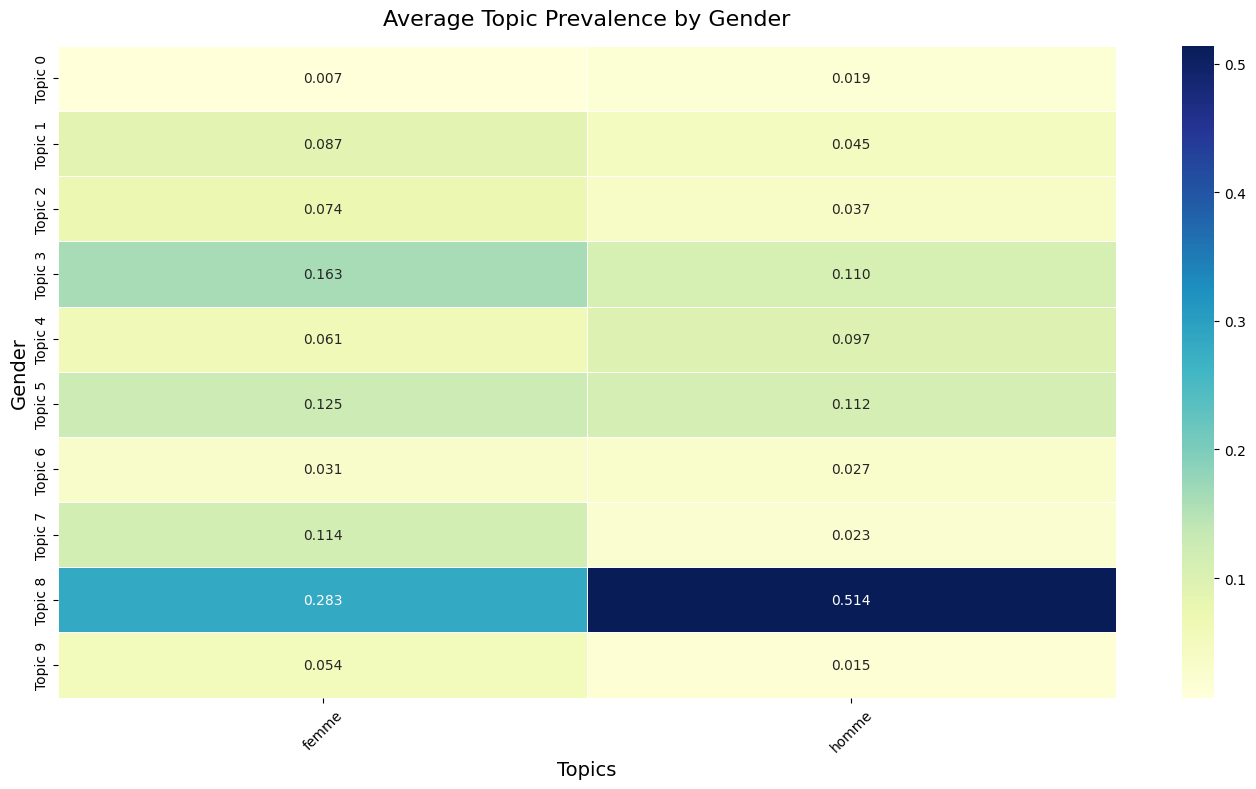

In [11]:
# Transform the vectorized text to get the topic distribution for every document
document_topics = lda_ten.transform(tf)

# Convert this matrix into a Pandas DataFrame 
num_topics = lda_ten.n_components
topic_column_names = [f"Topic {i}" for i in range(num_topics)]

topic_df_ten = pd.DataFrame(
    document_topics, 
    columns=topic_column_names, 
    index=filtered_df.index 
)

# Merge the topic distributions with the gender column 
merged_df_ten = pd.concat([filtered_df[['titulaire-sexe']], topic_df_ten], axis=1)

# Group by gender and calculate the mean for each topic column
prevalence_by_gender_ten = merged_df_ten.groupby('titulaire-sexe').mean()


# Visualize the results
plt.figure(figsize=(14, 8))
sns.heatmap(
    prevalence_by_gender_ten.T, 
    annot=True,          
    cmap="YlGnBu",       
    fmt=".3f",          
    linewidths=.5
)

plt.title("Average Topic Prevalence by Gender", fontsize=16, pad=15)
plt.ylabel("Gender", fontsize=14)
plt.xlabel("Topics", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Rename topics

In [12]:
topic_map_ten={"Topic 0" : "Alsatian & German",
    "Topic 1": "Socialist/PSU Autogestion", 
    "Topic 2": "Regalian Traditionalist Rhetoric", 
    "Topic 3": "Ecologist Entente & Green Politics",
    "Topic 4": "Elections & Local Mandates",
    "Topic 5" : "Left-Wing Partisan & Institutional Rhetoric", 
    "Topic 6": "Immigration & Insecurity (FN)",
    "Topic 7": "Gender & Labor Identity (LO/PC)",
    "Topic 8": "Socioeconomic & Regional Development",
    "Topic 9":"Far-Left Class Struggle"
}
prevalence_by_gender_ten.columns=[topic_map_ten.get(col,col) for col in prevalence_by_gender_ten.columns]
prevalence_by_gender_ten


,Alsatian & German,Socialist/PSU Autogestion,Regalian Traditionalist Rhetoric,Ecologist Entente & Green Politics,Elections & Local Mandates,Left-Wing Partisan & Institutional Rhetoric,Immigration & Insecurity (FN),Gender & Labor Identity (LO/PC),Socioeconomic & Regional Development,Far-Left Class Struggle
titulaire-sexe,,,,,,,,,,
femme,0.007055,0.087438,0.073529,0.163235,0.061297,0.125165,0.031290,0.114161,0.282687,0.054143
homme,0.018827,0.045319,0.037383,0.109548,0.097053,0.112462,0.027131,0.023011,0.513869,0.015397


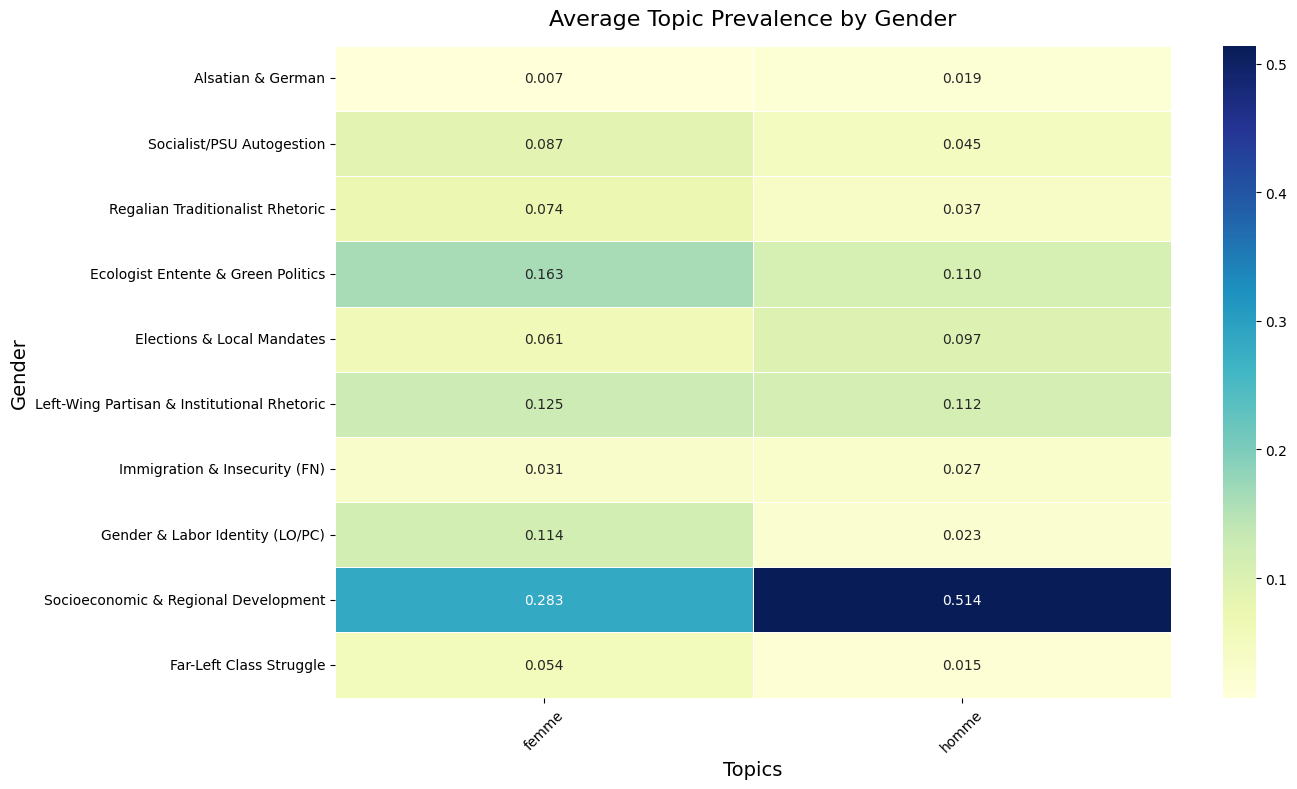

In [13]:
# Plot topic distributions by gender
plt.figure(figsize=(14, 8))
sns.heatmap(
    prevalence_by_gender_ten.T, 
    annot=True,          
    cmap="YlGnBu",       
    fmt=".3f",           
    linewidths=.5
)

plt.title("Average Topic Prevalence by Gender", fontsize=16, pad=15)
plt.ylabel("Gender", fontsize=14)
plt.xlabel("Topics", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Assess intra vs interdocument heterogeneity by gender

Average Manifesto Diversity by Gender:
                topic_entropy  num_prominent_topics
titulaire-sexe                                     
femme                0.687399              1.916204
homme                0.702875              1.922074
--------------------------------------------------


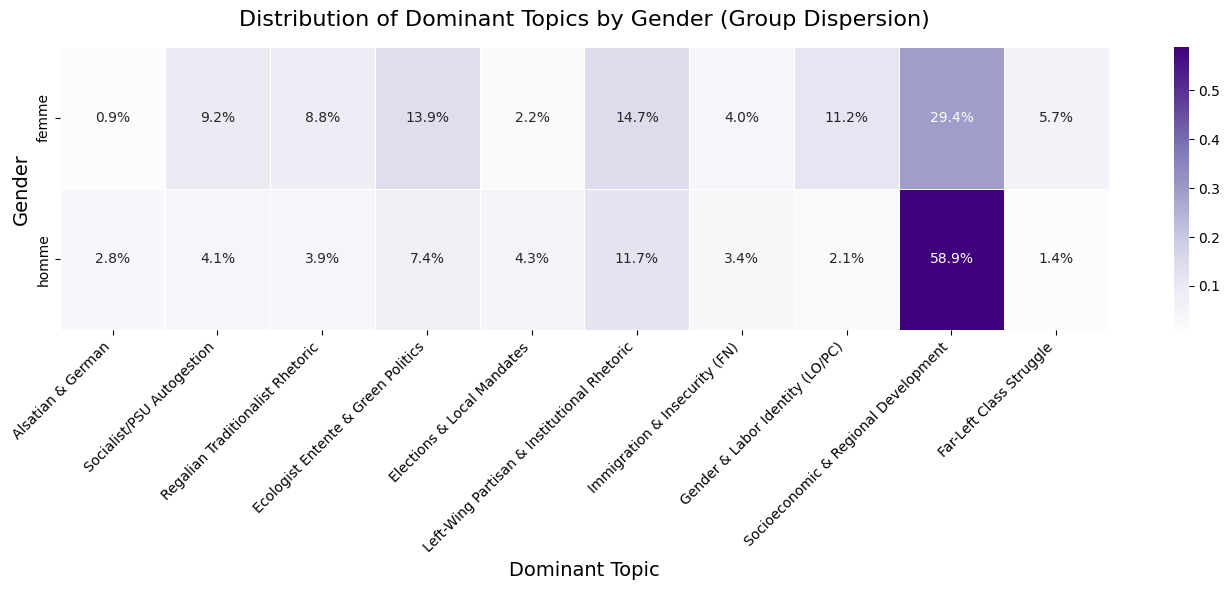

In [15]:
# --- 1. Measure Intra-Document Diversity  ---

# Calculate Entropy for each document's topic distribution
merged_df_ten['topic_entropy'] = topic_df_ten.apply(entropy, axis=1)

# Count how many topics have > 10% presence in the document
merged_df_ten['num_prominent_topics'] = (topic_df_ten > 0.1).sum(axis=1)

# Compare the average manifesto diversity by gender
document_diversity_by_gender = merged_df_ten.groupby('titulaire-sexe')[['topic_entropy', 'num_prominent_topics']].mean()
print("Average Manifesto Diversity by Gender:")
print(document_diversity_by_gender)
print("-" * 50)


# --- 2. Measure Group Dispersion  ---

# Find the dominant topic per manifesto (the topic with the highest probability)
merged_df_ten['dominant_topic'] = topic_df_ten.idxmax(axis=1)

# Calculate the proportion of manifestos assigned to each dominant topic, separated by gender
dominant_topic_dist = pd.crosstab(
    merged_df_ten['titulaire-sexe'], 
    merged_df_ten['dominant_topic'], 
    normalize='index' 
)

# Rename the columns using custom topic mapping
dominant_topic_dist = dominant_topic_dist.rename(columns=topic_map_ten)

# Plotting  group dispersion
plt.figure(figsize=(14, 6))
sns.heatmap(
    dominant_topic_dist, 
    annot=True, 
    cmap="Purples", 
    fmt=".1%", 
    linewidths=.5
)

plt.title("Distribution of Dominant Topics by Gender (Group Dispersion)", fontsize=16, pad=15)
plt.ylabel("Gender", fontsize=14)
plt.xlabel("Dominant Topic", fontsize=14)

# Adjust rotation and alignment 
plt.xticks(rotation=45, ha='right') 

plt.tight_layout()
plt.show()



# 15 TOPICS MODEL (EXTRA)

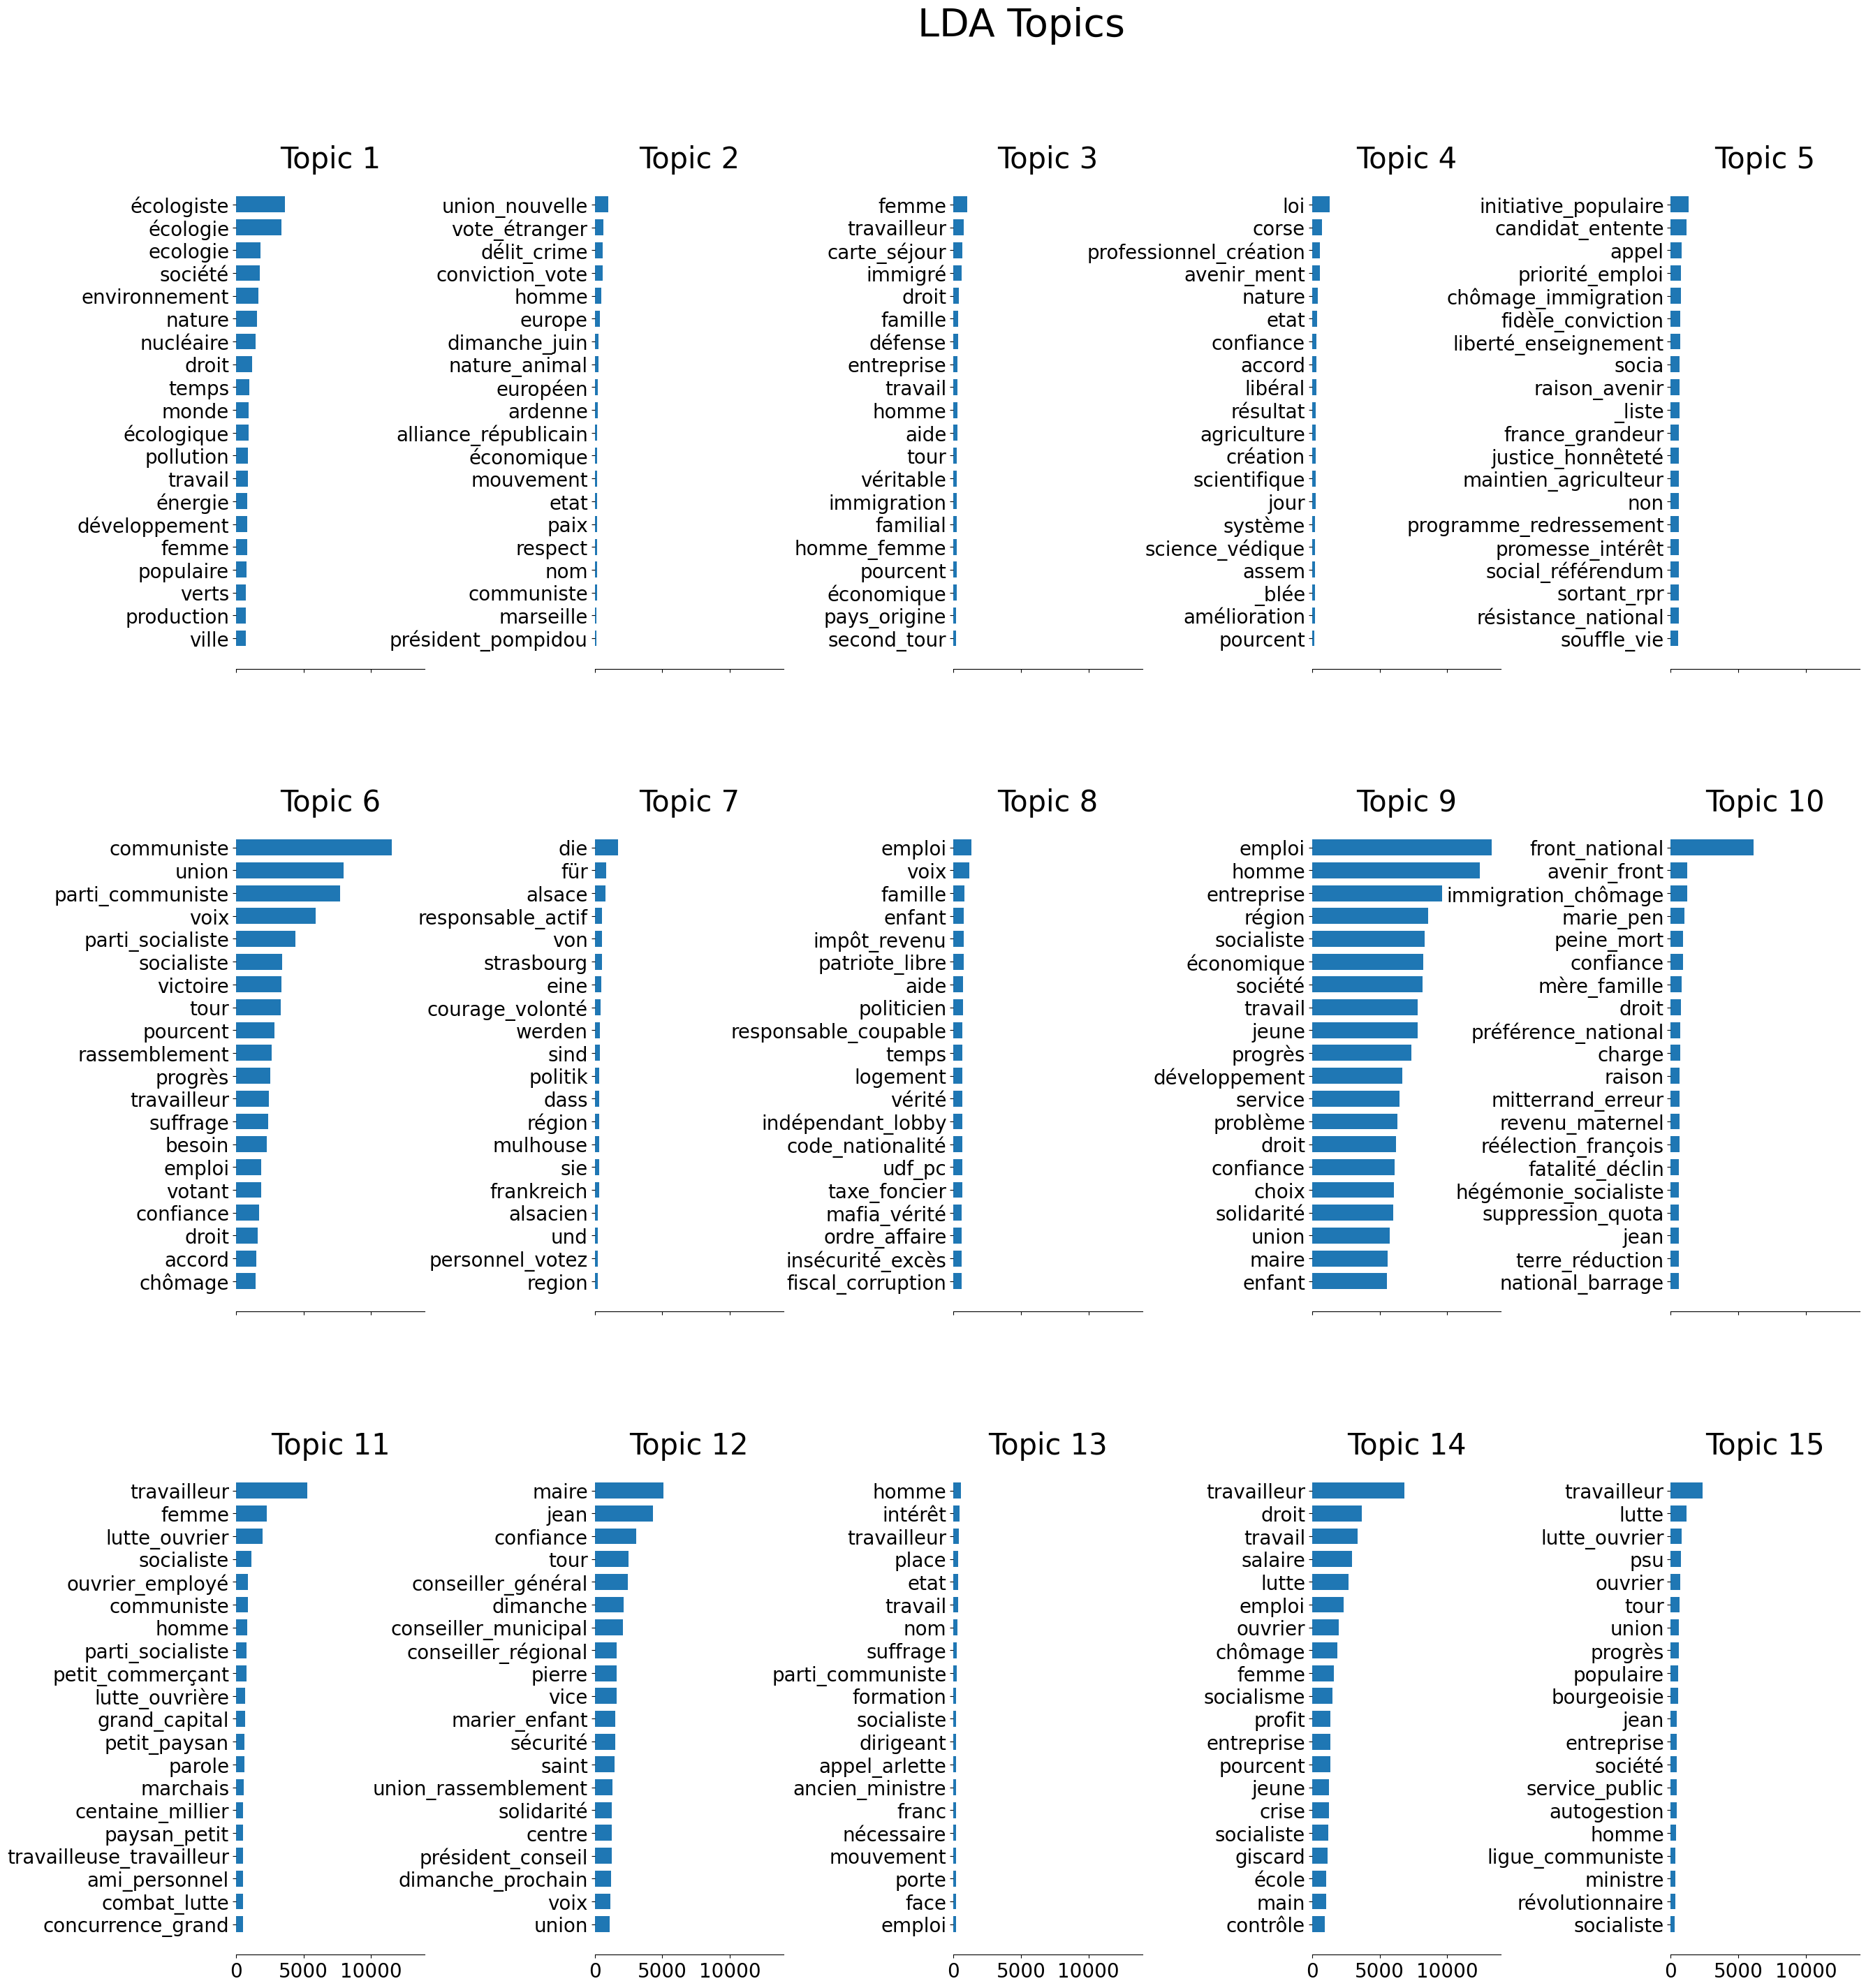

In [19]:
# Define Parameters
n_topics = 15
n_top_words = 20

# Fit the LDA Model
lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method="online",
    learning_offset=50.0,
    random_state=42,
)
lda.fit(tf)

# Plot the results
plot_top_words(lda, tf_vectorizer, n_top_words, "LDA Topics", nb_lines=3)


In [20]:
# Prepare the data 
lda_display = pyLDAvis.lda_model.prepare(lda, tf, tf_vectorizer, sort_topics =False)

# Display the interactive chart
pyLDAvis.display(lda_display)

### Gender Analysis

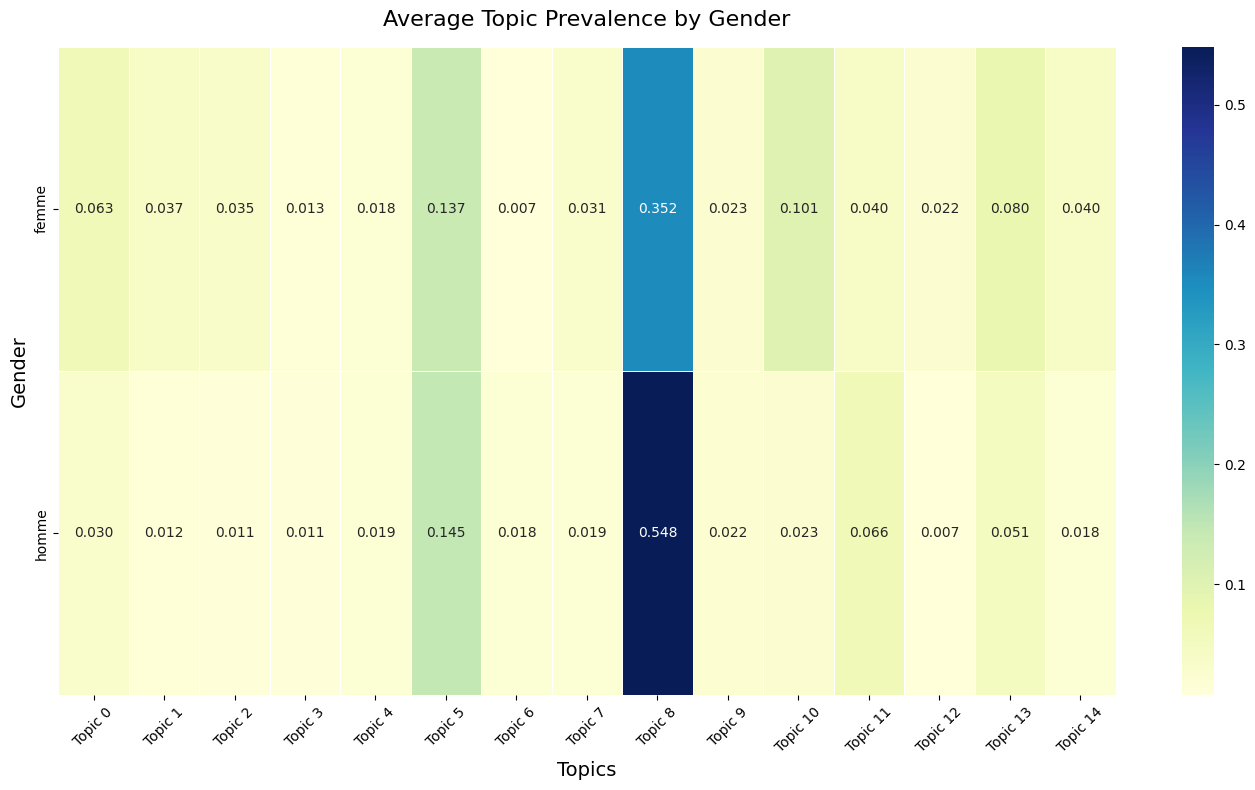

In [21]:
# Transform the vectorized text to get the topic distribution for every document
document_topics = lda.transform(tf)

# Convert this matrix into a Pandas DataFrame 
num_topics = lda.n_components
topic_column_names = [f"Topic {i}" for i in range(num_topics)]

topic_df = pd.DataFrame(
    document_topics, 
    columns=topic_column_names, 
    index=filtered_df.index 
)

# Merge the topic distributions with the gender column 
merged_df = pd.concat([filtered_df[['titulaire-sexe']], topic_df], axis=1)

# Group by gender and calculate the mean for each topic column
prevalence_by_gender = merged_df.groupby('titulaire-sexe').mean()


# Visualize the results
plt.figure(figsize=(14, 8))
sns.heatmap(
    prevalence_by_gender, 
    annot=True,          
    cmap="YlGnBu",       
    fmt=".3f",          
    linewidths=.5
)

plt.title("Average Topic Prevalence by Gender", fontsize=16, pad=15)
plt.ylabel("Gender", fontsize=14)
plt.xlabel("Topics", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Rename Topics

In [22]:
# Name topics
topic_map={
    "Topic 0" : "Ecologist Entente & Green Politics",
    "Topic 1" : "Identity & Institutional Politics",
    "Topic 2" : "Regalian Tradicionalist Rhetoric", 
    "Topic 3" : "Law, Governance & Institutional Trust", 
    "Topic 4" : "Right Wing Nationalist Reform", 
    "Topic 5" : "General Political Vocabulary",
    "Topic 6" : "Alsatian Regionalism & Cross-Border Identity", 
    "Topic 7" : "Immigration & Insecurity (FN)",
    "Topic 8" : "Economic & Regional Development", 
    "Topic 9" : "Nationalist/Populist Rhetoric",
    "Topic 10" : "Gender & Labor Identity (LO/PC)",
    "Topic 11": "Local Mandates & Mayoral Status",
    "Topic 12": "Parliamentary Discourse & Institutional Figures",
    "Topic 13": "Socio-Economics & Labor Rights", 
    "Topic 14": "Socialist/PSU Autogestion"
}

prevalence_by_gender.columns=[topic_map.get(col,col) for col in prevalence_by_gender.columns]

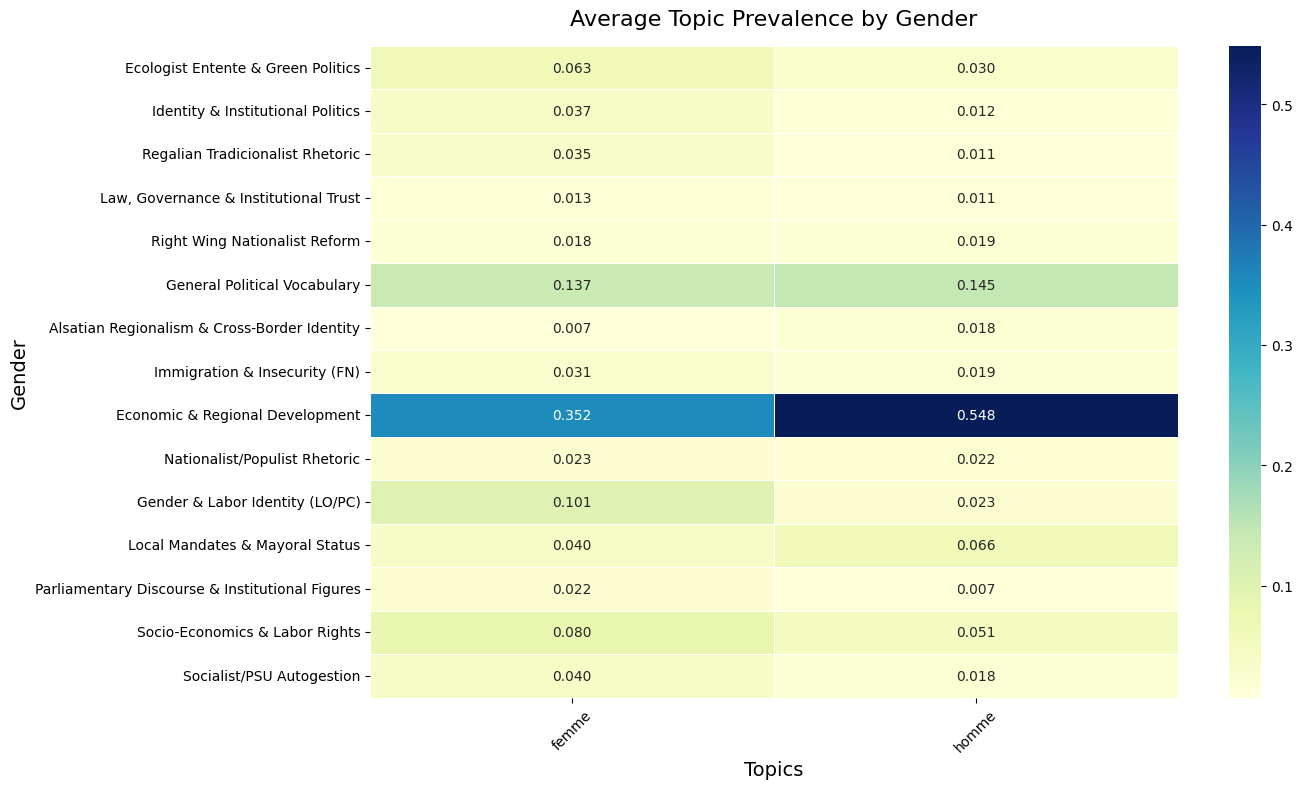

In [23]:
# Plot topic distributions by gender
plt.figure(figsize=(14, 8))
sns.heatmap(
    prevalence_by_gender.T, 
    annot=True,          
    cmap="YlGnBu",       
    fmt=".3f",           
    linewidths=.5
)

plt.title("Average Topic Prevalence by Gender", fontsize=16, pad=15)
plt.ylabel("Gender", fontsize=14)
plt.xlabel("Topics", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tuning the number of topics

## First Approach : based on C_v coherence and similarity

In [ ]:
feature_names = tf_vectorizer.get_feature_names_out()

# Define Parameters
num_topics_list = list(range(3, 21))
num_keywords = 15

LDA_models = {}
LDA_topics = {}

# Train several models with different k
for i in num_topics_list:
    print(f"Training LDA with {i} topics...")
    
    # Initialize LDA model
    lda = LatentDirichletAllocation(
        n_components=i,
        max_iter=10,               
        learning_method="online",  
        learning_offset=50.0,
        random_state=42,
        n_jobs=-1                  
    )
    
    # Fit the model to vectorized text
    lda.fit(tf)
    LDA_models[i] = lda
    
    # Extract the top words for each topic
    topics = []
    
    # Get the top words per topic
    for topic_idx, topic_weights in enumerate(lda.components_):
        # Get the indices of the top 'num_keywords' weights
        top_features_ind = topic_weights.argsort()[-num_keywords:][::-1]
        
        # Map indices back to the actual string words
        top_features = [feature_names[j] for j in top_features_ind]
        topics.append(top_features)
        
    LDA_topics[i] = topics

print("Training complete!")


Training LDA with 3 topics...
Training LDA with 4 topics...
Training LDA with 5 topics...
Training LDA with 6 topics...
Training LDA with 7 topics...
Training LDA with 8 topics...
Training LDA with 9 topics...
Training LDA with 10 topics...
Training LDA with 11 topics...
Training LDA with 12 topics...
Training LDA with 13 topics...
Training LDA with 14 topics...
Training LDA with 15 topics...
Training LDA with 16 topics...
Training LDA with 17 topics...
Training LDA with 18 topics...
Training LDA with 19 topics...
Training LDA with 20 topics...
Training complete!


In [ ]:
# Save trained models
results_to_save = {
    'models': LDA_models,
    'topics': LDA_topics
}
joblib.dump(results_to_save, project_root / 'temp/lda_training_results.joblib')

NameError: name 'LDA_models' is not defined

In [ ]:
# Import the saved models
#loaded_results = joblib.load(project_root / 'temp/lda_training_results.joblib')
#LDA_models = loaded_results['models']
#LDA_topics = loaded_results['topics']
#num_topics_list = list(range(3, 21))


### Obtain models average similarity

In [4]:
# Define Jaccard similarity between two topics
def jaccard_similarity(topic_1, topic_2):
    """
    Derives the Jaccard similarity of two topics

    Jaccard similarity:
    - A statistic used for comparing the similarity and diversity of sample sets
    - J(A,B) = (A ∩ B)/(A ∪ B)
    - Goal is low Jaccard scores for coverage of the diverse elements
    """
    intersection = set(topic_1).intersection(set(topic_2))
    union = set(topic_1).union(set(topic_2))
                    
    return float(len(intersection))/float(len(union))

In [ ]:
# Obtain
LDA_stability = {}
for i in range(0, len(num_topics_list)-1):
    jaccard_sims = []
    for t1, topic1 in enumerate(LDA_topics[num_topics_list[i]]): # pylint: disable=unused-variable
        sims = []
        for t2, topic2 in enumerate(LDA_topics[num_topics_list[i+1]]): # pylint: disable=unused-variable
            sims.append(jaccard_similarity(topic1, topic2))    
        
        jaccard_sims.append(sims)    
    
    LDA_stability[num_topics_list[i]] = jaccard_sims
                
mean_stabilities = [np.array(LDA_stability[i]).mean() for i in num_topics_list[:-1]]

### Obtain models mean coherence score

In [ ]:
# Extract the exact tokenization from vectorizer
analyzer = tf_vectorizer.build_analyzer()

# Tokenize the documents
tokenized_texts = [analyzer(str(doc)) for doc in documents]

# Build the Gensim dictionary
gensim_dict = Dictionary(tokenized_texts)

# Obtain coherence scores 
coherences = []
print("Starting coherence calculations...")


for i in num_topics_list[:-1]:
    cm = CoherenceModel(
        topics=LDA_topics[i], 
        texts=tokenized_texts,     
        dictionary=gensim_dict,   
        coherence='c_v'
    )
    
    score = cm.get_coherence()
    coherences.append(score)
    print(f"Model with {i} topics -> Coherence (c_v): {score:.4f}")

Starting coherence calculations...
Model with 3 topics -> Coherence (c_v): 0.3750
Model with 4 topics -> Coherence (c_v): 0.3792
Model with 5 topics -> Coherence (c_v): 0.4776
Model with 6 topics -> Coherence (c_v): 0.4598
Model with 7 topics -> Coherence (c_v): 0.4937
Model with 8 topics -> Coherence (c_v): 0.5224
Model with 9 topics -> Coherence (c_v): 0.5815
Model with 10 topics -> Coherence (c_v): 0.5846
Model with 11 topics -> Coherence (c_v): 0.5629
Model with 12 topics -> Coherence (c_v): 0.5479
Model with 13 topics -> Coherence (c_v): 0.5416
Model with 14 topics -> Coherence (c_v): 0.5498
Model with 15 topics -> Coherence (c_v): 0.5572
Model with 16 topics -> Coherence (c_v): 0.5441
Model with 17 topics -> Coherence (c_v): 0.5127
Model with 18 topics -> Coherence (c_v): 0.5094
Model with 19 topics -> Coherence (c_v): 0.5093


# Plot average coherence vs similarity across models

In [ ]:
coh_sta_diffs = [coherences[i] - mean_stabilities[i] for i in range(num_keywords)[:-1]] 
coh_sta_max = max(coh_sta_diffs)
coh_sta_max_idxs = [i for i, j in enumerate(coh_sta_diffs) if j == coh_sta_max]
ideal_topic_num_index = coh_sta_max_idxs[0] 
ideal_topic_num = num_topics_list[ideal_topic_num_index]
coh_max=max(coherences)
idea_topic_num_index_coh_max_idxs = [i for i, j in enumerate(coherences) if j == coh_max]
ideal_topic_num_index_coh_max = idea_topic_num_index_coh_max_idxs[0]
ideal_topic_num_coh_max = num_topics_list[ideal_topic_num_index_coh_max]

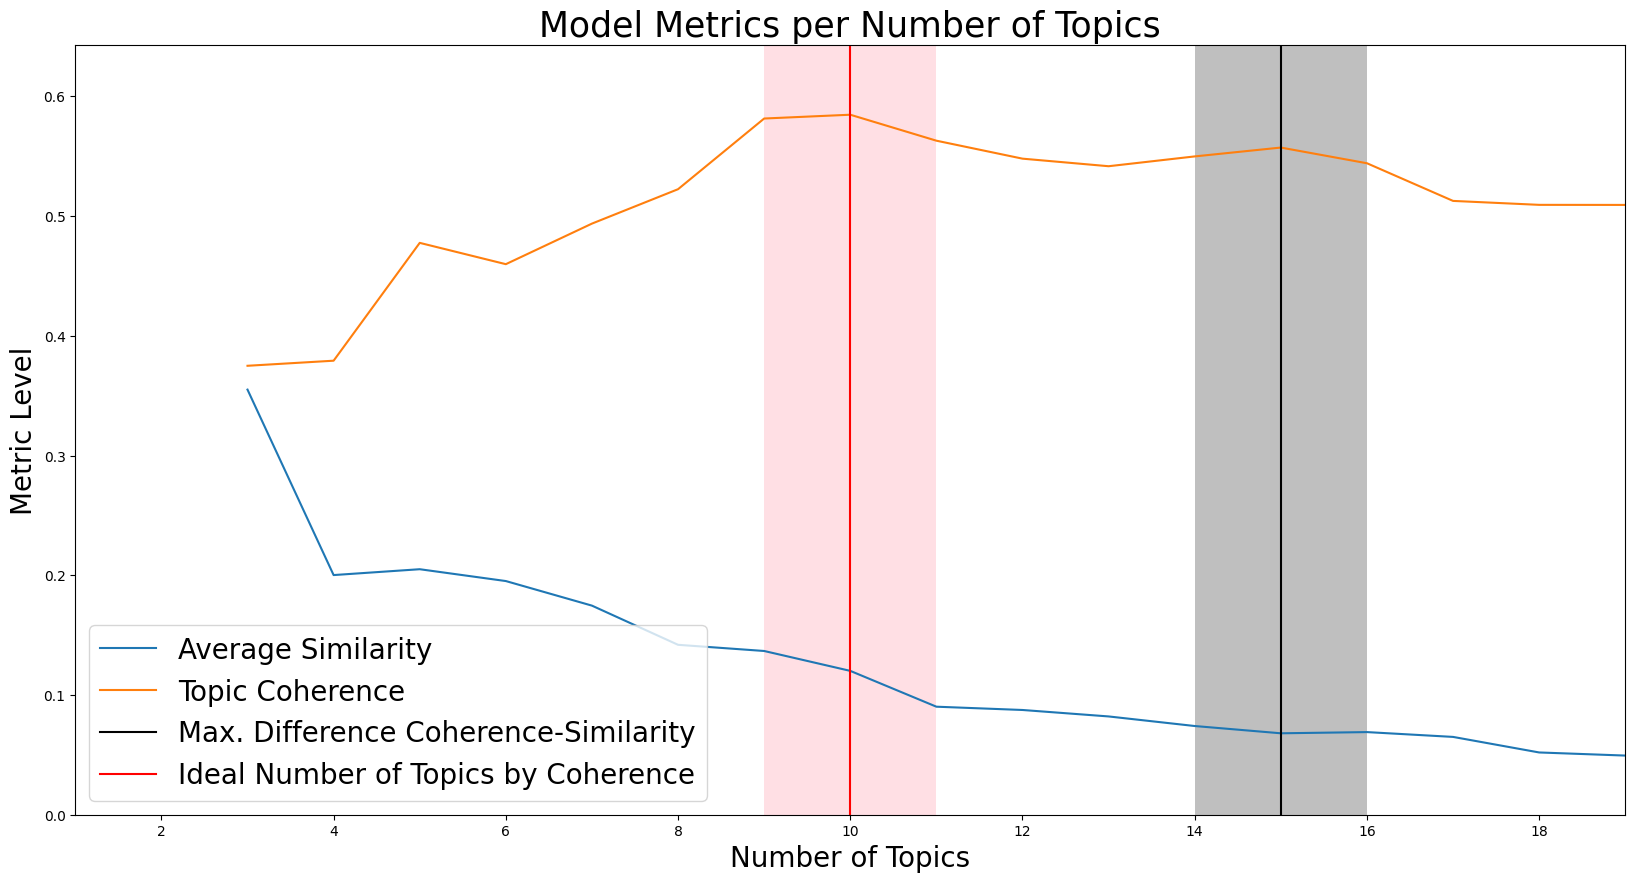

In [17]:
plt.figure(figsize=(20,10))
ax = sns.lineplot(x=num_topics_list[:-1], y=mean_stabilities, label='Average Similarity')
ax = sns.lineplot(x=num_topics_list[:-1], y=coherences, label='Topic Coherence')

ax.axvline(x=ideal_topic_num, label='Max. Difference Coherence-Similarity', color='black')
ax.axvspan(xmin=ideal_topic_num - 1, xmax=ideal_topic_num + 1, alpha=0.5, facecolor='grey')

ax.axvline(x=ideal_topic_num_coh_max, label='Ideal Number of Topics by Coherence', color='red')
ax.axvspan(xmin=ideal_topic_num_coh_max - 1, xmax=ideal_topic_num_coh_max + 1, alpha=0.5, facecolor='pink')

y_max = max(max(mean_stabilities), max(coherences)) + (0.10 * max(max(mean_stabilities), max(coherences)))
ax.set_ylim([0, y_max])
ax.set_xlim([1, num_topics_list[-1]-1])
                
ax.axes.set_title('Model Metrics per Number of Topics', fontsize=25)
ax.set_ylabel('Metric Level', fontsize=20)
ax.set_xlabel('Number of Topics', fontsize=20)
plt.legend(fontsize=20)
plt.show()   